#Neural Network

##1. Import Libraries

In [ ]:
!pip install tensorflow opencv-python matplotlib scikit-learn seaborn pandas tqdm

In [ ]:
import numpy as np
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import os
import cv2
import random
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, classification_report
import requests
import zipfile
import shutil
from tqdm import tqdm

##2. Load Stanford 40 Dataset

In [ ]:
DATASET_URL = "http://vision.stanford.edu/Datasets/Stanford40.zip"
DATASET_PATH = "/content/stanford40"
os.makedirs(DATASET_PATH, exist_ok=True)

# progress bar
print("Downloading Stanford 40 dataset...")
response = requests.get(DATASET_URL, stream=True)
total_size = int(response.headers.get('content-length', 0))
zip_path = os.path.join(DATASET_PATH, "stanford40.zip")

with open(zip_path, "wb") as f:
    for chunk in tqdm(response.iter_content(chunk_size=1024), total=total_size//1024 + 1):
        if chunk:
            f.write(chunk)

# Extract dataset
print("Extracting dataset...")
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(DATASET_PATH)

100%|██████████| 301204/301204 [00:18<00:00, 16635.08it/s]


Extracting dataset...


In [ ]:
# Verify dataset structure and fix if needed
images_path = os.path.join(DATASET_PATH, "JPEGImages")
if os.path.exists(images_path):
    print(f"Found {len(os.listdir(images_path))} images")

    # Check if images are organized in class folders (they aren't by default)
    # Stanford40 has a different structure - we need to reorganize based on action classes
    print("Organizing images into class folders...")

    # Load action class information
    actions_file = os.path.join(DATASET_PATH, "ImageSplits", "actions.txt")
    class_folders = []

    if os.path.exists(actions_file):
      with open(actions_file, 'r') as f:
        lines = f.readlines()[1:]  # Skip header row
        class_folders = [line.split('\t')[0].strip() for line in lines]


        # Create class directories
        organized_path = os.path.join(DATASET_PATH, "organized_classes")
        os.makedirs(organized_path, exist_ok=True)

        for class_name in class_folders:
            os.makedirs(os.path.join(organized_path, class_name), exist_ok=True)

            # Find images for this class
            class_file = os.path.join(DATASET_PATH, "ImageSplits", f"{class_name}_train.txt")
            if os.path.exists(class_file):
                with open(class_file, 'r') as f:
                    for line in f.readlines():
                        img_name = line.strip()
                        src_path = os.path.join(images_path, img_name)
                        if os.path.exists(src_path):
                            shutil.copy(src_path, os.path.join(organized_path, class_name, img_name))

            class_file = os.path.join(DATASET_PATH, "ImageSplits", f"{class_name}_test.txt")
            if os.path.exists(class_file):
                with open(class_file, 'r') as f:
                    for line in f.readlines():
                        img_name = line.strip()
                        src_path = os.path.join(images_path, img_name)
                        if os.path.exists(src_path):
                            shutil.copy(src_path, os.path.join(organized_path, class_name, img_name))

        # Update dataset path to use the organized structure
        DATASET_PATH = organized_path
        print(f"Dataset organized into {len(class_folders)} class folders")
    else:
        print("Warning: Could not find actions.txt file. Dataset may not be properly structured.")
else:
    print("Warning: Expected dataset structure not found!")

Found 9532 images
Organizing images into class folders...
Dataset organized into 40 class folders


In [ ]:
# After the dataset is organized, select only a subset of classes
# If you want to train on the entire datste comment out this section
# Remember, to train on the full datset would require more epochs and lots more time for the model to become good
SELECTED_CLASSES = ['applauding', 'cooking', 'drinking', 'reading']  # Choose any 4 classes

# Create a new directory for the subset
SUBSET_PATH = os.path.join(DATASET_PATH, "../stanford40_subset")
os.makedirs(SUBSET_PATH, exist_ok=True)

# Copy only the selected classes
for class_name in SELECTED_CLASSES:
    src_path = os.path.join(DATASET_PATH, class_name)
    dst_path = os.path.join(SUBSET_PATH, class_name)
    if os.path.exists(src_path):
        shutil.copytree(src_path, dst_path, dirs_exist_ok=True)

# Update the dataset path to use the subset
DATASET_PATH = SUBSET_PATH

##3. Dataset Exploration and Preprocessing



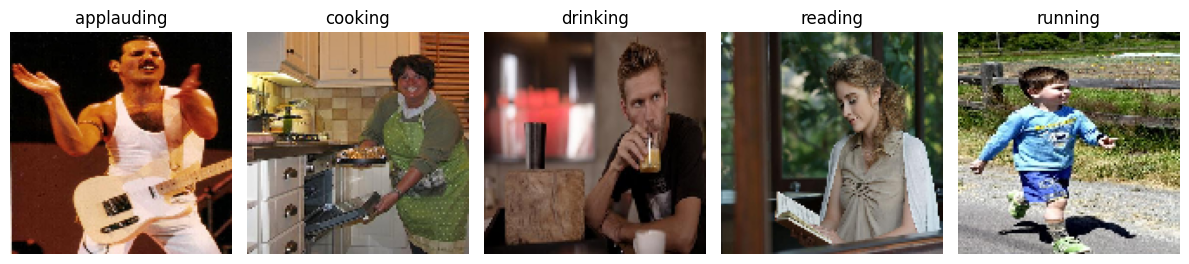

In [ ]:
# Get class names
class_names = sorted(os.listdir(DATASET_PATH))

# Set up figure
plt.figure(figsize=(12, 8))
IMG_SIZE = (128, 128)

for i, class_name in enumerate(class_names[:5]):  # Display up to 5 classes
    class_path = os.path.join(DATASET_PATH, class_name)
    if not os.path.isdir(class_path):
        continue  # Skip if not a directory

    # Randomly select an image from the class
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    # Load and display image
    img = load_img(img_path, target_size=IMG_SIZE)
    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Set parameters
IMG_SIZE = (320, 320)
BATCH_SIZE = 64
EPOCHS = 80
VALIDATION_SPLIT = 0.2


In [ ]:
# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=VALIDATION_SPLIT
)

In [ ]:
# rescaling for validation
val_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
# Create data generators
train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)


Found 860 images belonging to 4 classes.


In [ ]:
validation_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 213 images belonging to 4 classes.


In [ ]:
# Get class indices and number of classes
class_indices = train_generator.class_indices
num_classes = len(class_indices)
class_names = list(class_indices.keys())

print(f"Found {num_classes} classes: {class_names}")
print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {validation_generator.samples}")

Found 4 classes: ['applauding', 'cooking', 'drinking', 'reading']
Training samples: 860
Validation samples: 213


##4. Build Custom CNN Model

In [ ]:
def build_custom_cnn():
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),

        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),

        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),

        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.3),

        Conv2D(512, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(512, (3, 3), activation='relu', padding='same'),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.3),

        Flatten(),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])

    # Compile model
    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss='categorical_crossentropy',
        metrics=['accuracy', tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top_3_accuracy')]
    )

    return model

In [ ]:
# Set up callbacks for training
callbacks = [
    EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    ModelCheckpoint('stanford40_custom_cnn_best.h5', save_best_only=True, monitor='val_accuracy')
]

In [ ]:
print("\n=== TRAINING CUSTOM CNN MODEL ===\n")
model = build_custom_cnn()
model.summary()


=== TRAINING CUSTOM CNN MODEL ===



/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 224, 224, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 224, 224, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 112, 112, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 112, 112, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 56, 56, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 56, 56, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 28, 28, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 28, 28, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 28, 28, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 14, 14, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 7,936,612 (30.28 MB)

 Trainable params: 7,934,372 (30.27 MB)

 Non-trainable params: 2,240 (8.75 KB)

##5. Train Custom Model

In [ ]:
# Train model
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS,
    callbacks=callbacks
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 503ms/step - accuracy: 0.2313 - loss: 2.3367 - top_3_accuracy: 0.7622

54/54 ━━━━━━━━━━━━━━━━━━━━ 59s 670ms/step - accuracy: 0.2315 - loss: 2.3351 - top_3_accuracy: 0.7620 - val_accuracy: 0.2676 - val_loss: 1.5357 - val_top_3_accuracy: 0.7371 - learning_rate: 1.0000e-04
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 15s 270ms/step - accuracy: 0.2755 - loss: 2.0527 - top_3_accuracy: 0.7655 - val_accuracy: 0.2394 - val_loss: 1.6191 - val_top_3_accuracy: 0.7371 - learning_rate: 1.0000e-04
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 15s 282ms/step - accuracy: 0.2187 - loss: 1.9315 - top_3_accuracy: 0.7630 - val_accuracy: 0.2394 - val_loss: 1.5162 - val_top_3_accuracy: 0.7371 - learning_rate: 1.0000e-04
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 16s 295ms/step - accuracy: 0.2625 - loss: 1.8399 - top_3_accuracy: 0.8002 - val_accuracy: 0.2394 - val_loss: 1.5675 - val_top_3_accuracy: 0.7700 - learning_rate: 1.0000e-04
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 15s 271ms/step - accuracy: 0.2516 - loss: 1.7651 - top_3_accuracy: 0.7931 - val_accuracy: 0.2629 - val_loss: 1.7322 - val_top_3_a

##6. Model Evaluation

In [ ]:
# Evaluate the model
print("\n=== EVALUATING MODEL ===\n")
loss, accuracy, top3_acc = model.evaluate(validation_generator)
print(f"Validation Accuracy: {accuracy * 100:.2f}%")
print(f"Top-3 Accuracy: {top3_acc * 100:.2f}%")


=== EVALUATING MODEL ===

14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 180ms/step - accuracy: 0.1270 - loss: 1.7287 - top_3_accuracy: 0.4507
Validation Accuracy: 23.94%
Top-3 Accuracy: 73.71%


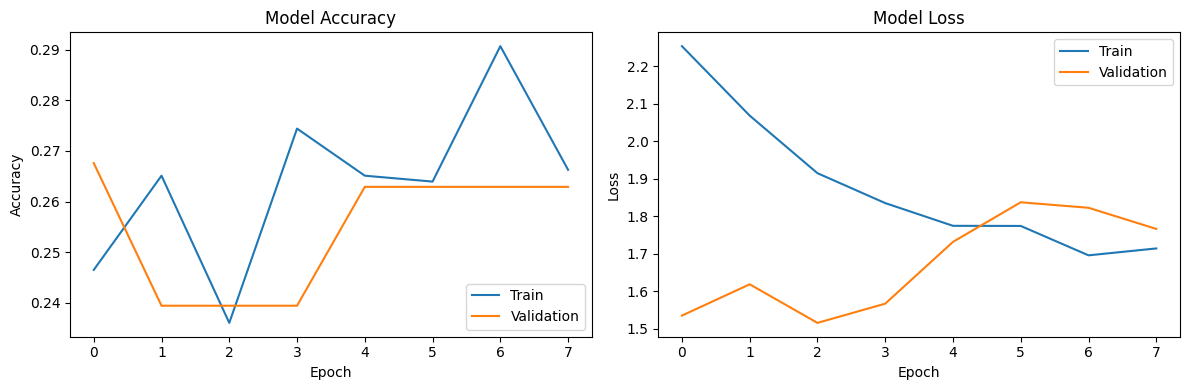

In [ ]:

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.tight_layout()
plt.savefig('training_history.png')
plt.show()

In [ ]:
# Confusion Matrix and Class-wise Performance
validation_generator.reset()
y_true = validation_generator.classes
y_pred = np.argmax(model.predict(validation_generator), axis=1)

14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 244ms/step


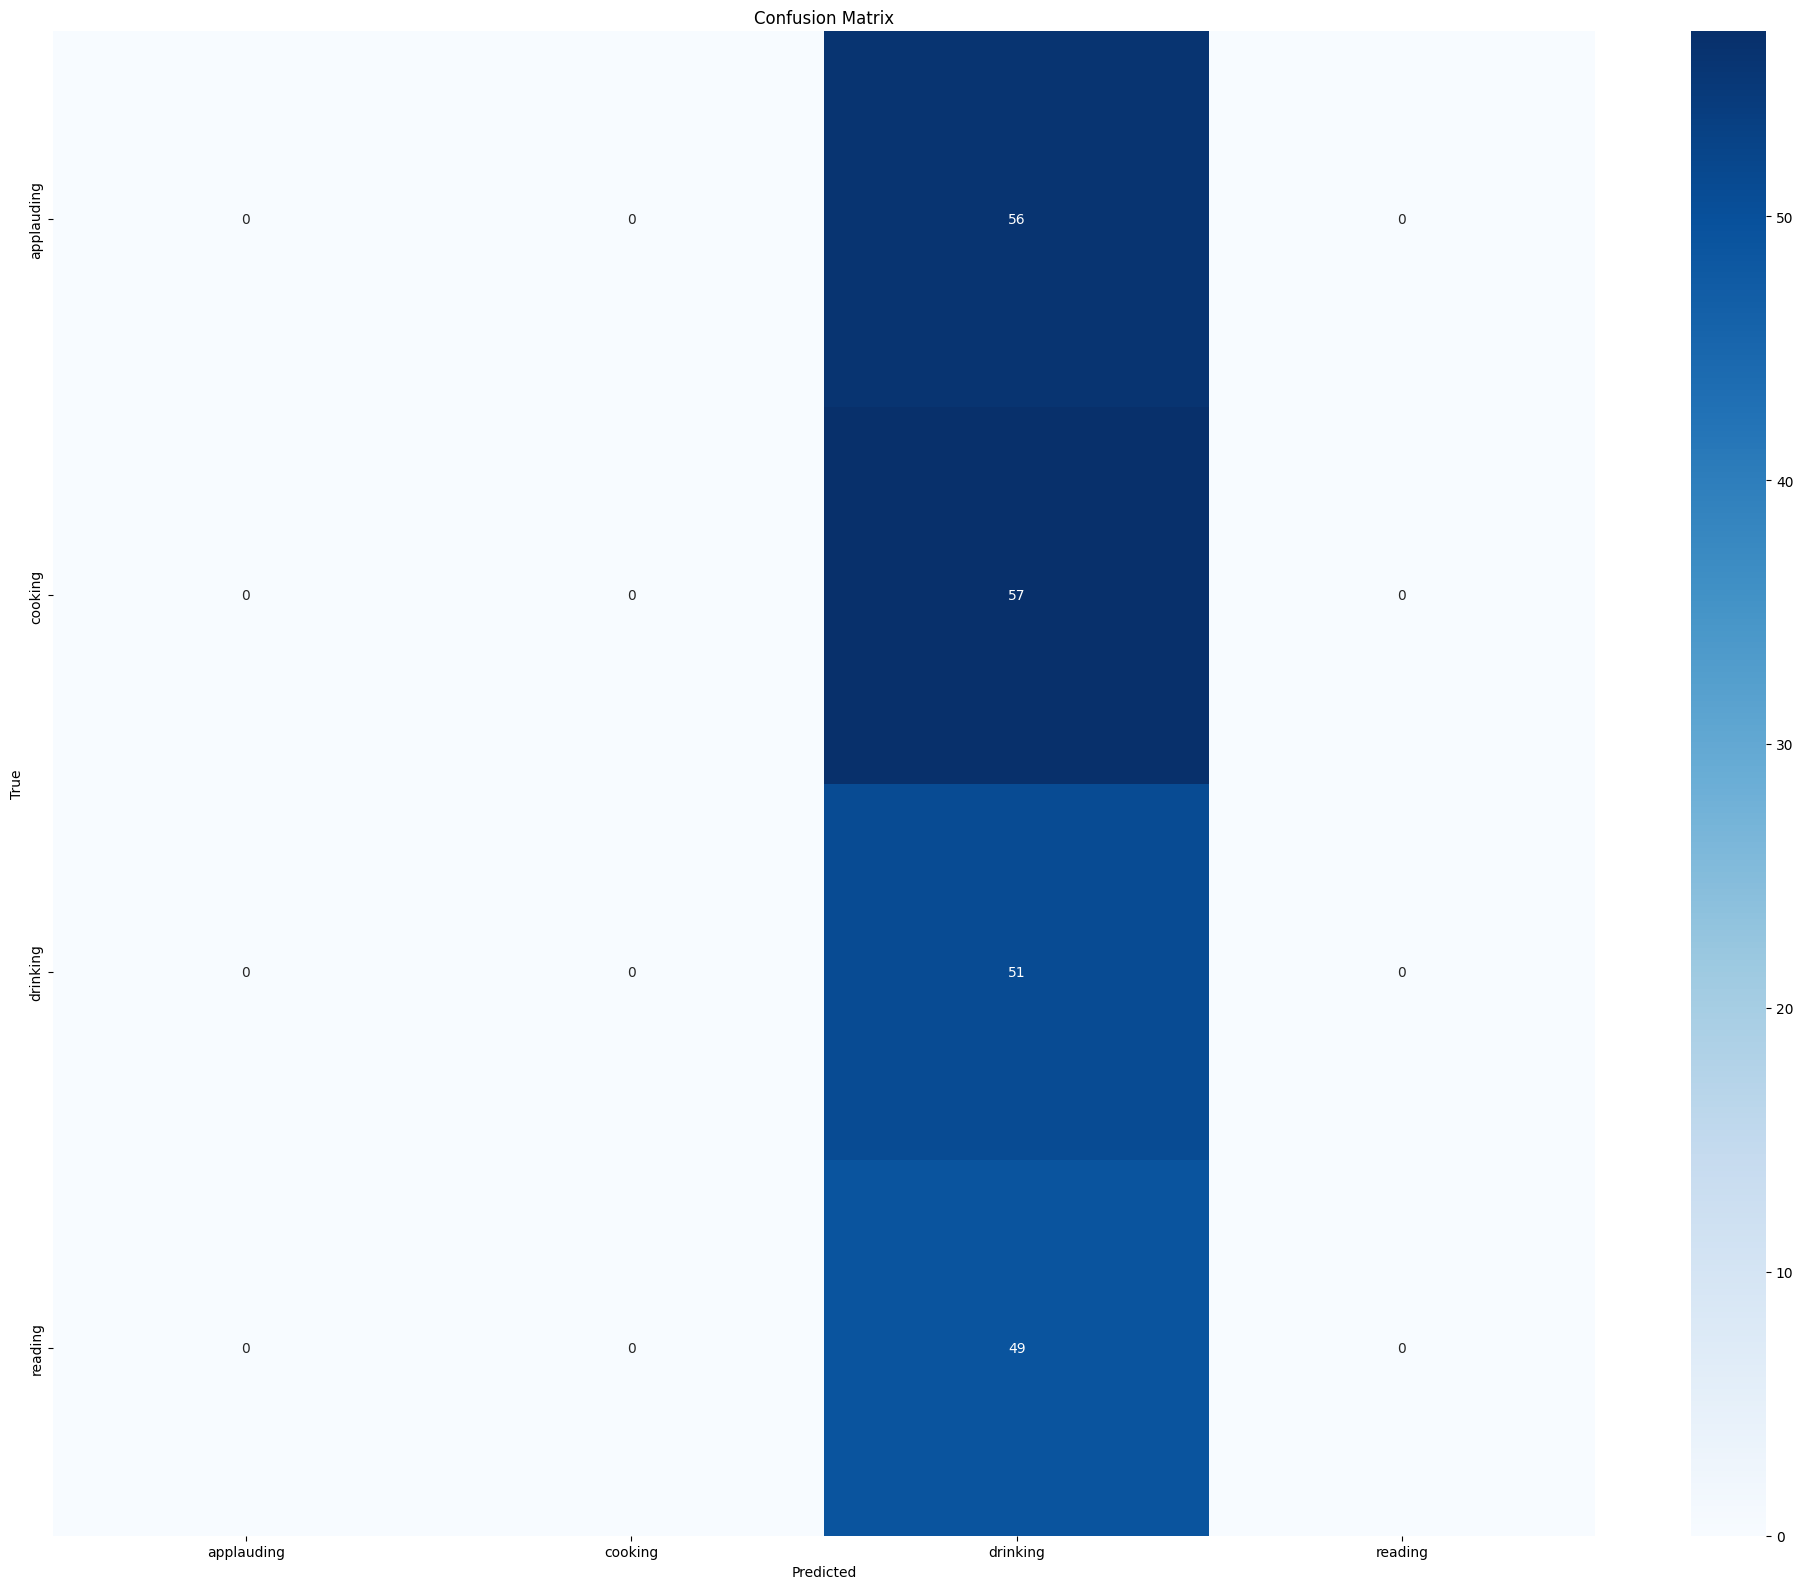

In [ ]:
# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(20, 16))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 717ms/step


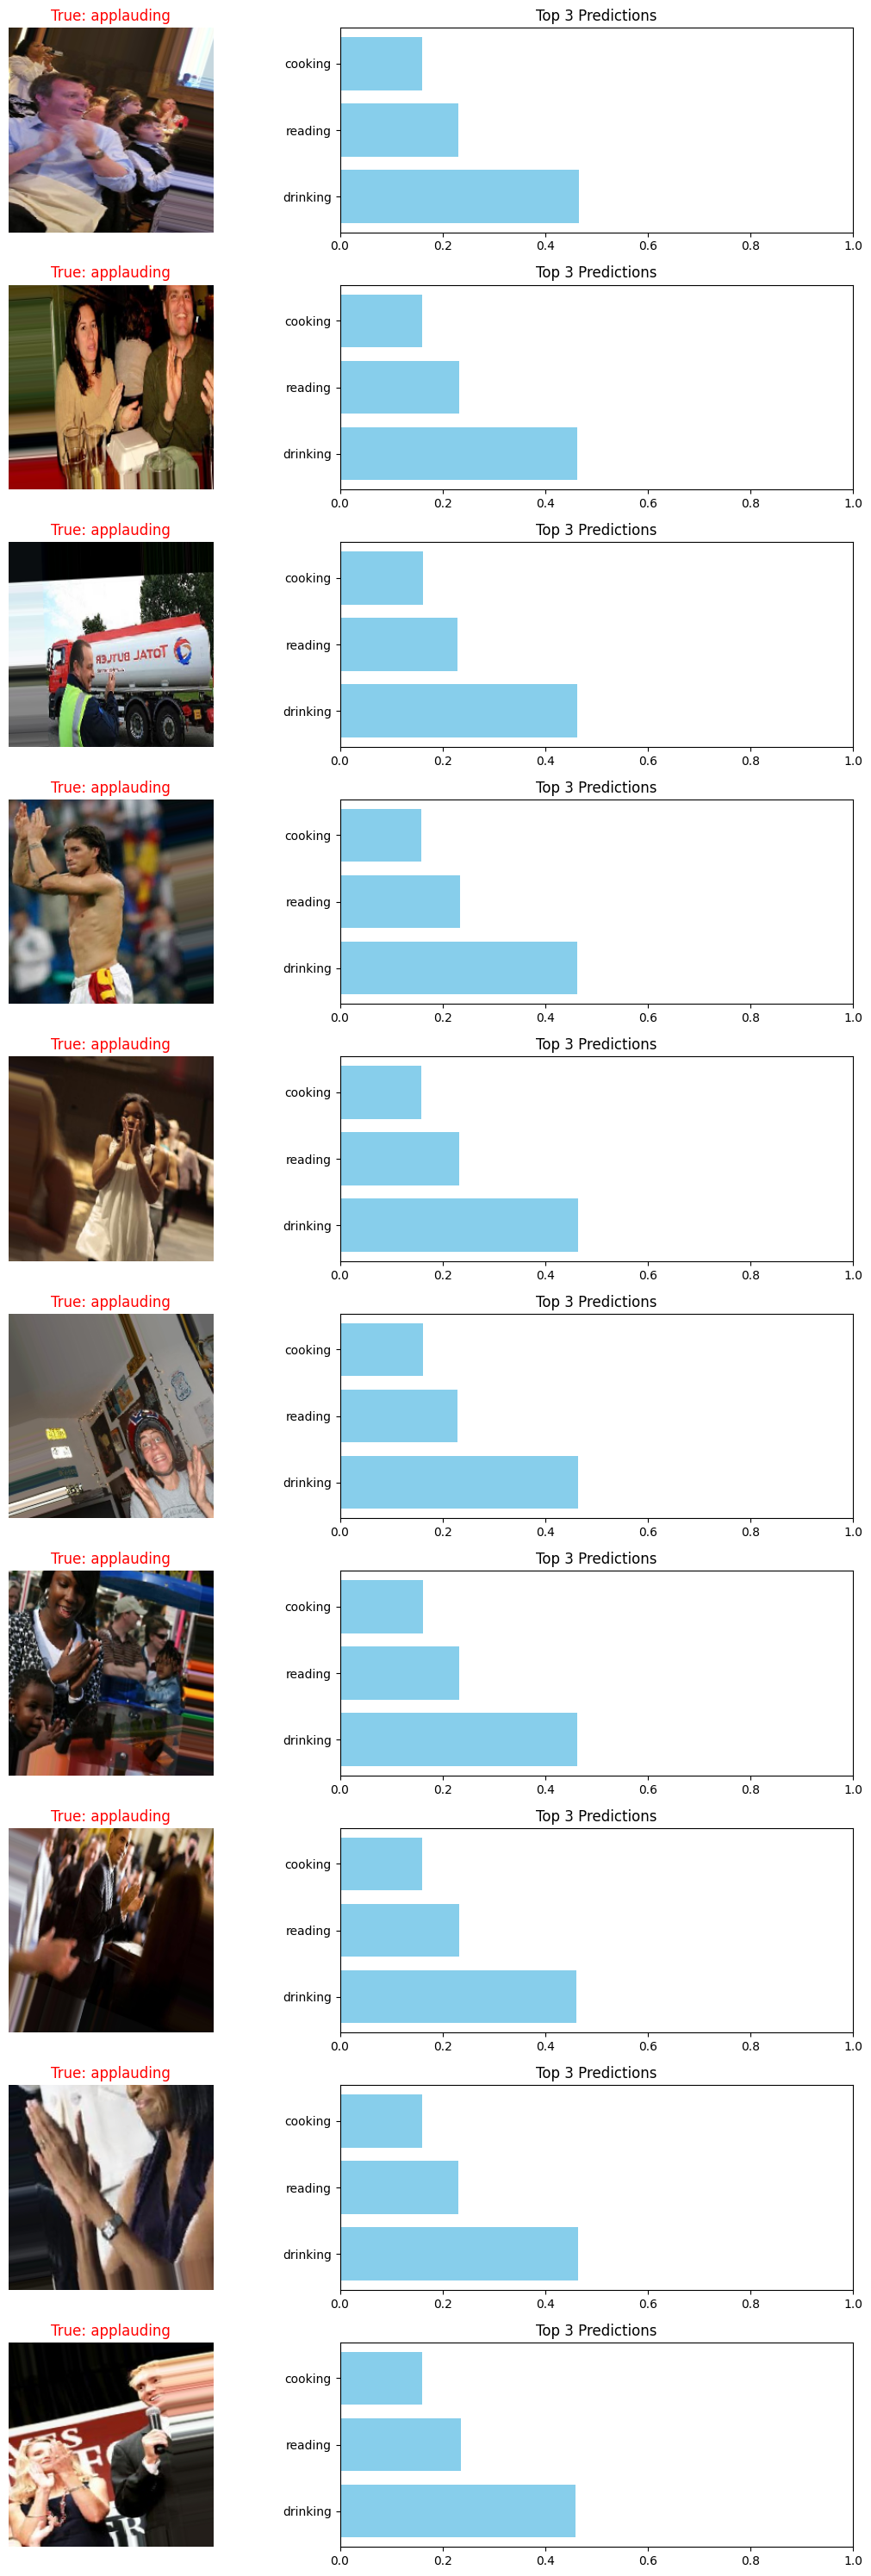

In [ ]:
# Visualize Model Predictions and Errors
def visualize_predictions(model, generator, num_samples=10):
    generator.reset()
    # Get a batch of images
    images, labels = next(generator)
    predictions = model.predict(images)

    fig, axes = plt.subplots(num_samples, 2, figsize=(12, num_samples*3))

    for i in range(min(num_samples, len(images))):
        # Display image
        axes[i, 0].imshow(images[i])
        true_class = np.argmax(labels[i])
        pred_class = np.argmax(predictions[i])

        # Set color based on correctness
        title_color = 'green' if true_class == pred_class else 'red'

        axes[i, 0].set_title(f"True: {class_names[true_class]}", color=title_color)
        axes[i, 0].axis('off')

        # Display prediction probabilities
        sorted_indices = np.argsort(predictions[i])[::-1][:3]  # Top 3 predictions
        for j, idx in enumerate(sorted_indices):
            bar_color = 'green' if idx == true_class else 'skyblue'
            axes[i, 1].barh(j, predictions[i][idx], color=bar_color)
            axes[i, 1].set_yticks(range(3))
            axes[i, 1].set_yticklabels([class_names[idx] for idx in sorted_indices])

        axes[i, 1].set_xlim(0, 1)
        axes[i, 1].set_title("Top 3 Predictions")

    plt.tight_layout()
    plt.savefig('sample_predictions.png')
    plt.show()

visualize_predictions(model, validation_generator)

#Unsupervised Learning

##1. Load and Explore the Dataset:

For demonstration, we'll use the Iris dataset

In [ ]:
from sklearn.datasets import load_iris

# Load the dataset
iris = load_iris()
data = pd.DataFrame(iris.data, columns=iris.feature_names)

# Display the first few rows
data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


##2. Data Preprocessing:



Standardize the data to have a mean of 0 and a standard deviation of 1

In [ ]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

##3. Dimensionality Reduction with PCA:

Reduce the dataset to two principal components for visualization

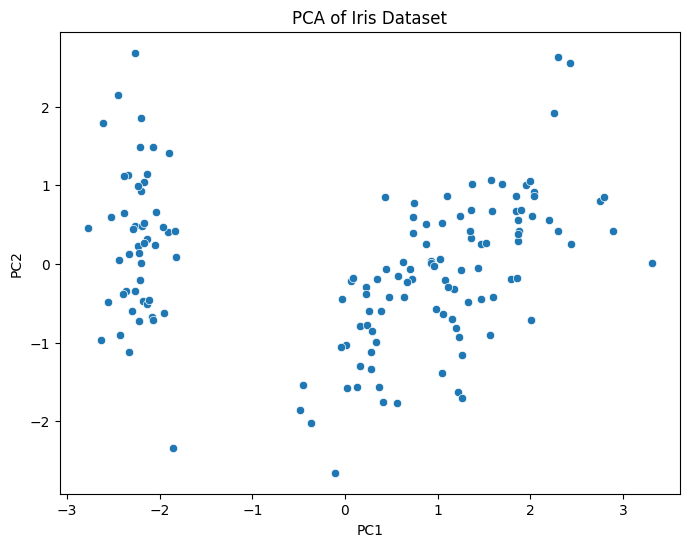

In [ ]:
pca = PCA(n_components=2)
principal_components = pca.fit_transform(scaled_data)

# Create a DataFrame with the principal components
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

# Plot the PCA result
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PC1', y='PC2', data=pca_df)
plt.title('PCA of Iris Dataset')
plt.show()

##4. Clustering with K-Means:

Apply K-Means clustering to the dataset

In [ ]:
# Determine the optimal number of clusters using the elbow method
inertia = []
for n in range(1, 11):
    kmeans = KMeans(n_clusters=n, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

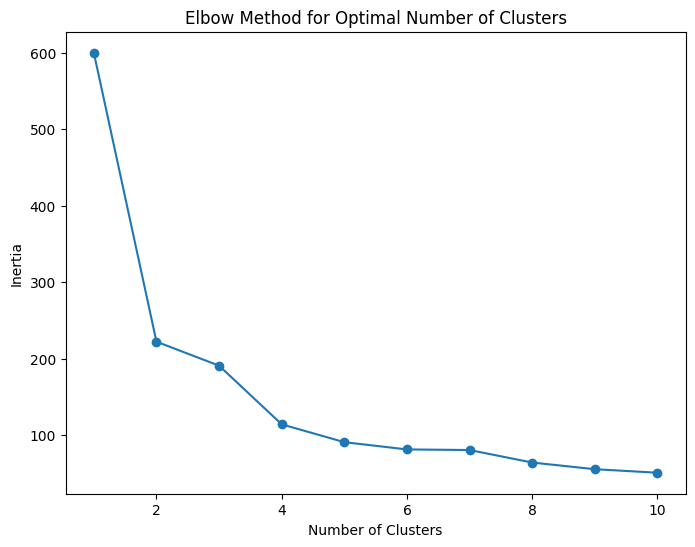

In [ ]:
# Plot the elbow curve
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

In [ ]:
# From the elbow plot, choose the optimal number of clusters (e.g., 3)
optimal_clusters = 3
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

In [ ]:
# Add the cluster labels to the PCA DataFrame
pca_df['Cluster'] = clusters

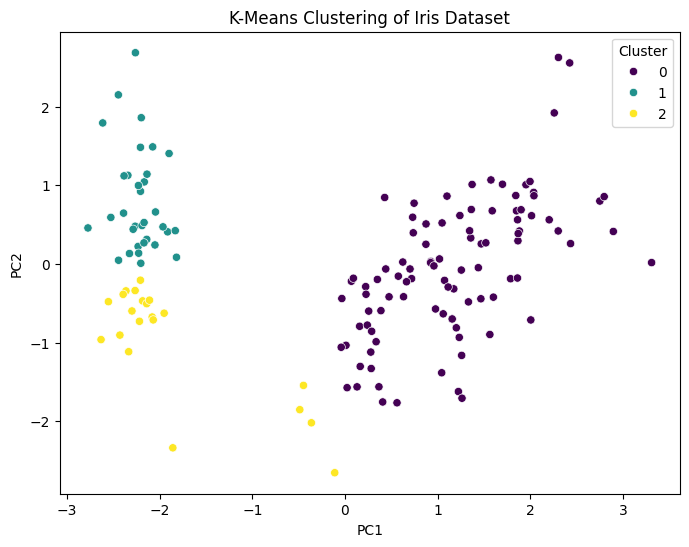

In [ ]:
# Plot the clustered data
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', palette='viridis', data=pca_df)
plt.title('K-Means Clustering of Iris Dataset')
plt.show()